In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
filename = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
df=pd.read_csv(filename)

In [3]:
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.shape

(1470, 35)

In [6]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [7]:
df["Attrition"].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

In [8]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [9]:
df.groupby("Department")['Attrition'].value_counts()

Department              Attrition
Human Resources         No            51
                        Yes           12
Research & Development  No           828
                        Yes          133
Sales                   No           354
                        Yes           92
Name: count, dtype: int64

In [10]:
attrition_rate = df.groupby("Department")['Attrition'].value_counts(normalize=True).unstack()
attrition_rate['Yes']

Department
Human Resources           0.190476
Research & Development    0.138398
Sales                     0.206278
Name: Yes, dtype: float64

In [11]:
category_cols = categorical_cols.drop("Attrition")
print(category_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [12]:
for col in category_cols:
    print(f"\n--- {col} ---")
    attrition_rate = df.groupby(col)['Attrition'].value_counts(normalize=True).unstack(fill_value=0)
    if "Yes" in attrition_rate.columns:
        print(attrition_rate["Yes"].sort_values(ascending=False))
    else:
        print("No 'yes' values found")


--- BusinessTravel ---
BusinessTravel
Travel_Frequently    0.249097
Travel_Rarely        0.149569
Non-Travel           0.080000
Name: Yes, dtype: float64

--- Department ---
Department
Sales                     0.206278
Human Resources           0.190476
Research & Development    0.138398
Name: Yes, dtype: float64

--- EducationField ---
EducationField
Human Resources     0.259259
Technical Degree    0.242424
Marketing           0.220126
Life Sciences       0.146865
Medical             0.135776
Other               0.134146
Name: Yes, dtype: float64

--- Gender ---
Gender
Male      0.170068
Female    0.147959
Name: Yes, dtype: float64

--- JobRole ---
JobRole
Sales Representative         0.397590
Laboratory Technician        0.239382
Human Resources              0.230769
Sales Executive              0.174847
Research Scientist           0.160959
Manufacturing Director       0.068966
Healthcare Representative    0.068702
Manager                      0.049020
Research Director           


--- BusinessTravel ---


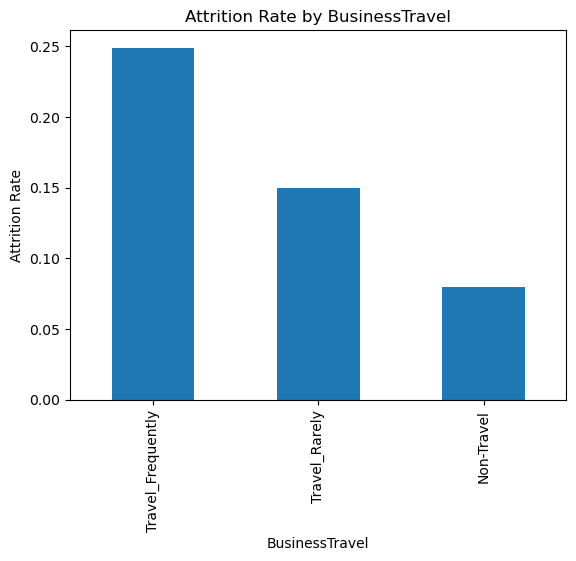


--- Department ---


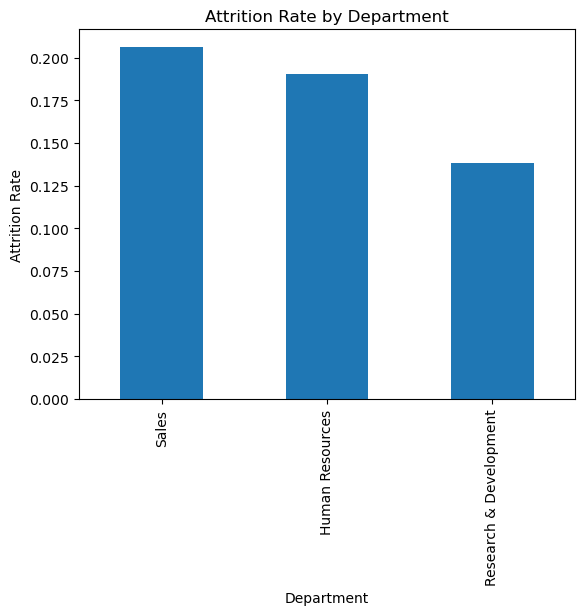


--- EducationField ---


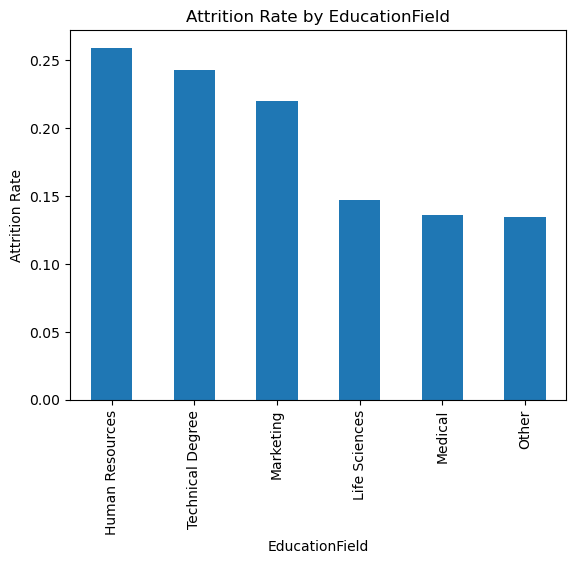


--- Gender ---


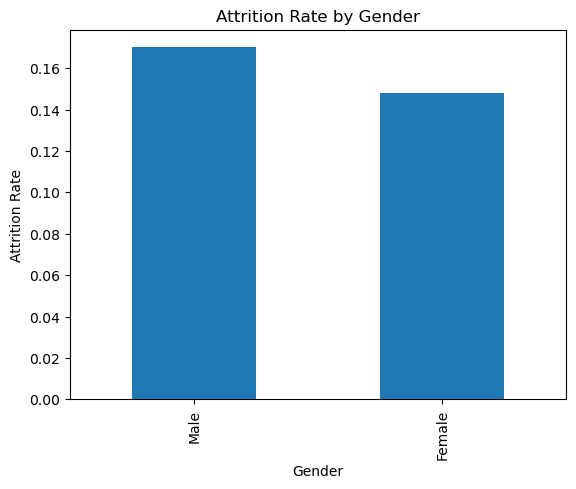


--- JobRole ---


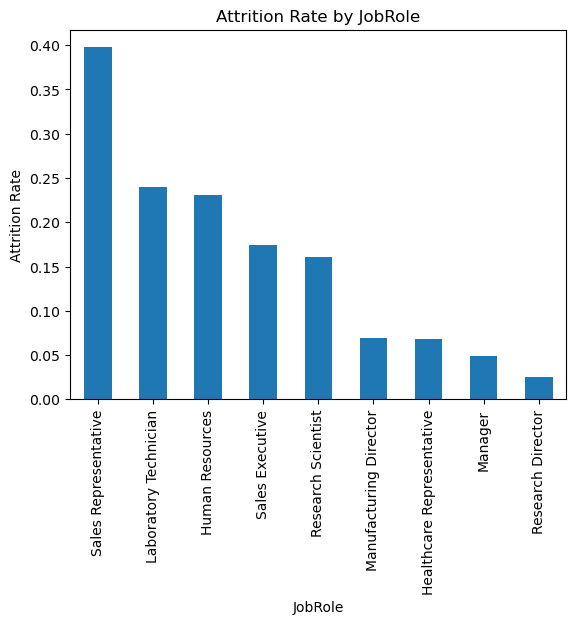


--- MaritalStatus ---


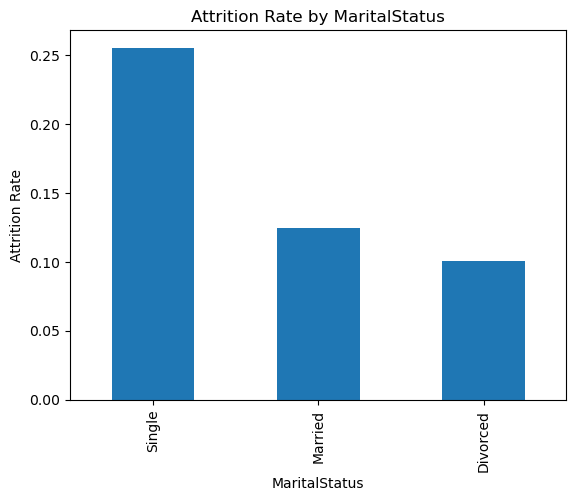


--- Over18 ---


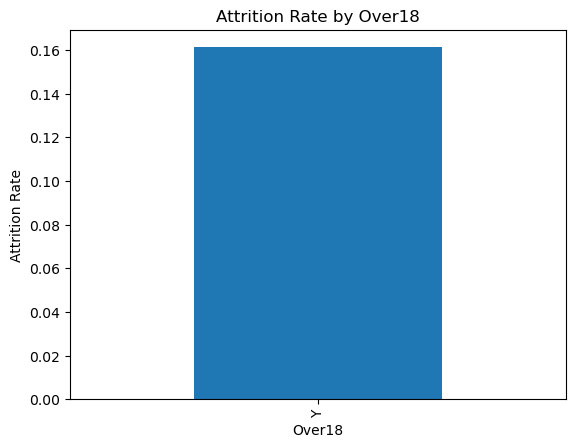


--- OverTime ---


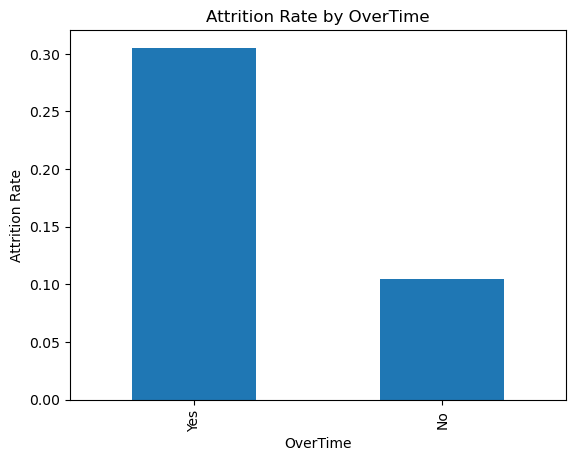

In [13]:
for col in category_cols:
    print(f"\n--- {col} ---")
    attrition_rate = df.groupby(col)['Attrition'].value_counts(normalize=True).unstack(fill_value=0)
    if "Yes" in attrition_rate.columns:
        attrition_rate["Yes"].sort_values(ascending=False).plot(kind="bar", title=f"Attrition Rate by {col}")
        plt.ylabel("Attrition Rate")
        plt.show()

In [14]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
print(numerical_cols)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [15]:
for col in numerical_cols:
    print(f"\n--- {col} ---")
    print(df.groupby("Attrition")[col].mean())



--- Age ---
Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64

--- DailyRate ---
Attrition
No     812.504461
Yes    750.362869
Name: DailyRate, dtype: float64

--- DistanceFromHome ---
Attrition
No      8.915653
Yes    10.632911
Name: DistanceFromHome, dtype: float64

--- Education ---
Attrition
No     2.927007
Yes    2.839662
Name: Education, dtype: float64

--- EmployeeCount ---
Attrition
No     1.0
Yes    1.0
Name: EmployeeCount, dtype: float64

--- EmployeeNumber ---
Attrition
No     1027.656123
Yes    1010.345992
Name: EmployeeNumber, dtype: float64

--- EnvironmentSatisfaction ---
Attrition
No     2.771290
Yes    2.464135
Name: EnvironmentSatisfaction, dtype: float64

--- HourlyRate ---
Attrition
No     65.952149
Yes    65.573840
Name: HourlyRate, dtype: float64

--- JobInvolvement ---
Attrition
No     2.770479
Yes    2.518987
Name: JobInvolvement, dtype: float64

--- JobLevel ---
Attrition
No     2.145985
Yes    1.637131
Name: JobLevel, dtype: float64

--- J

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\838537381.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6,4))


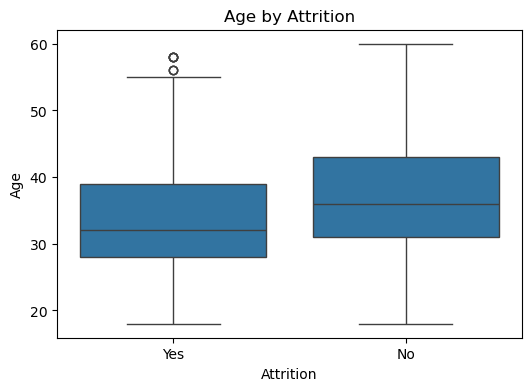

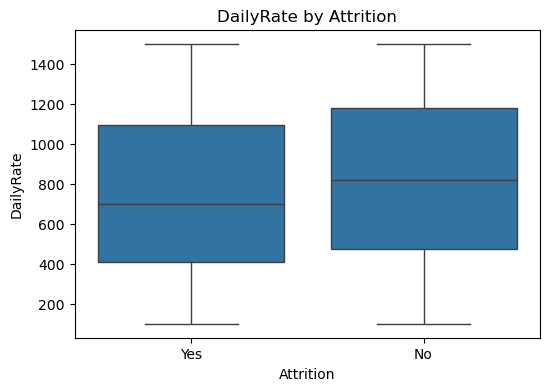

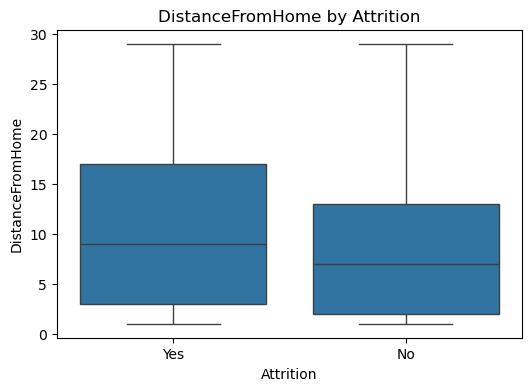

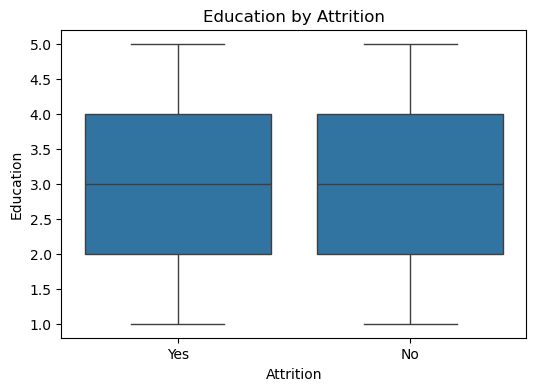

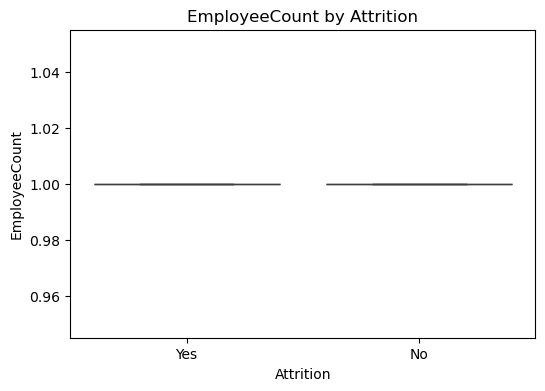

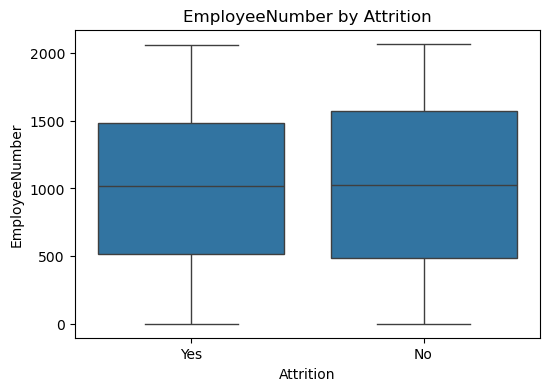

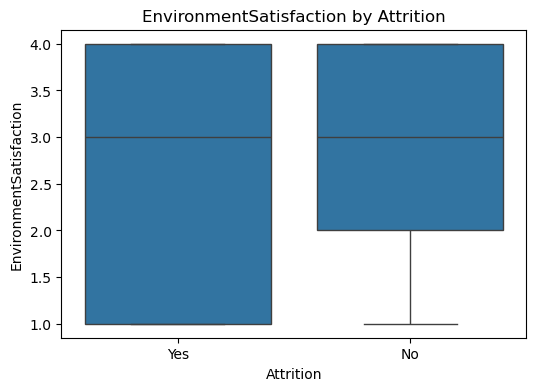

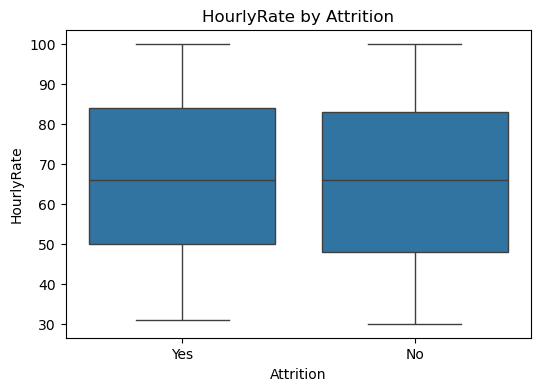

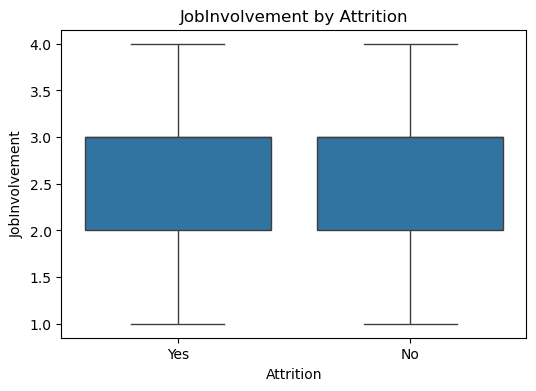

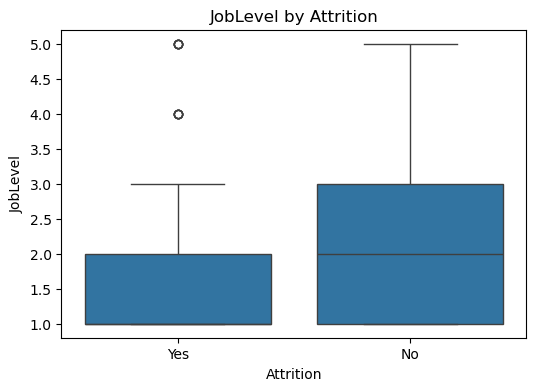

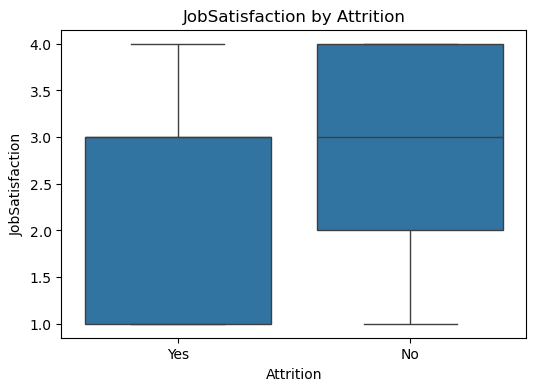

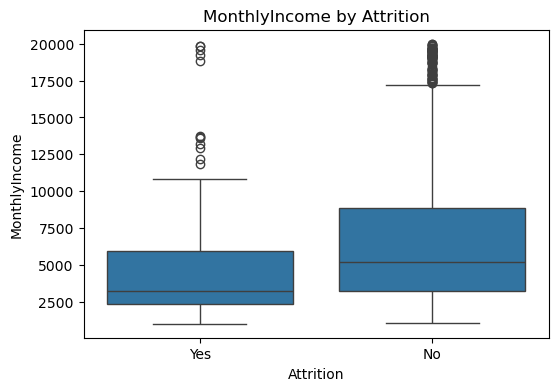

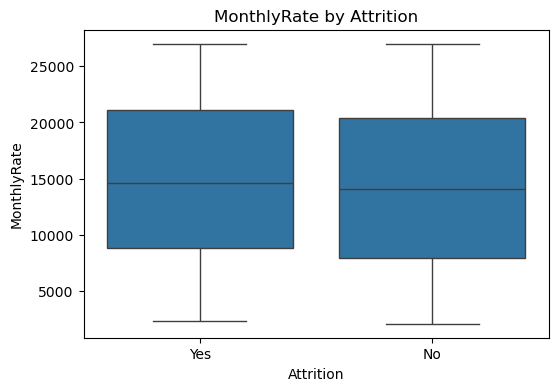

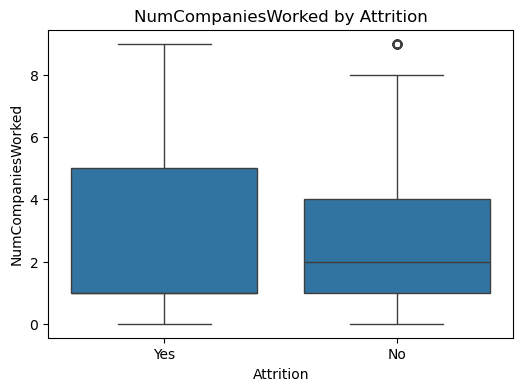

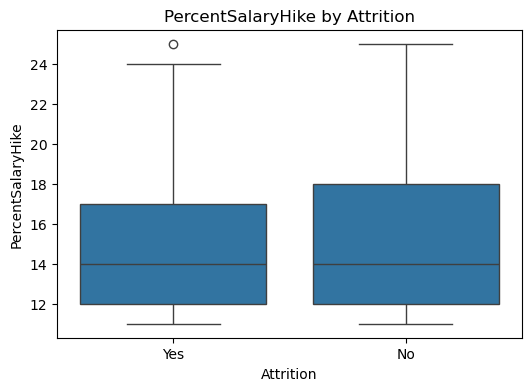

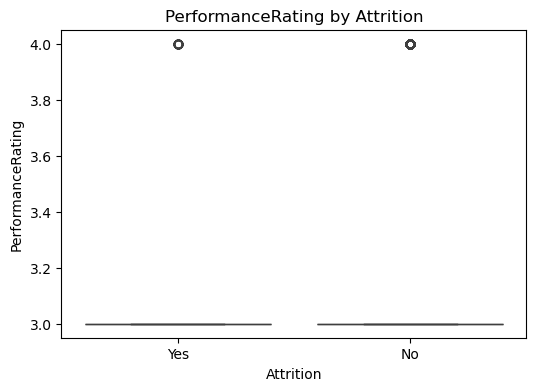

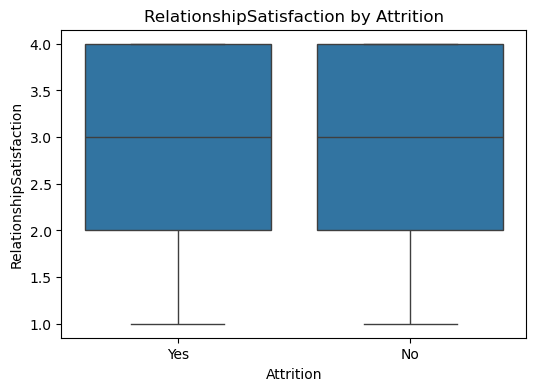

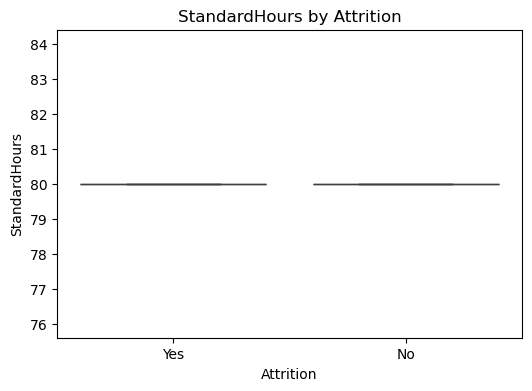

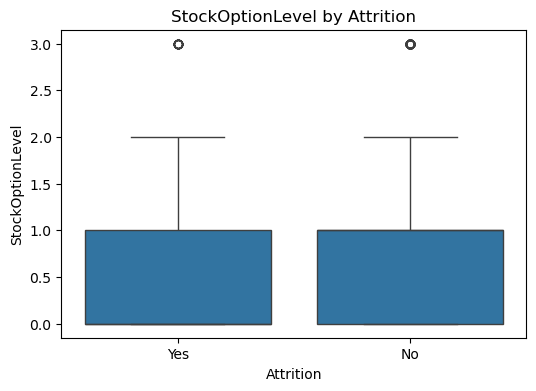

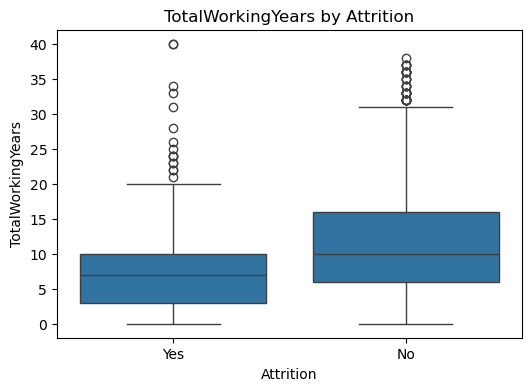

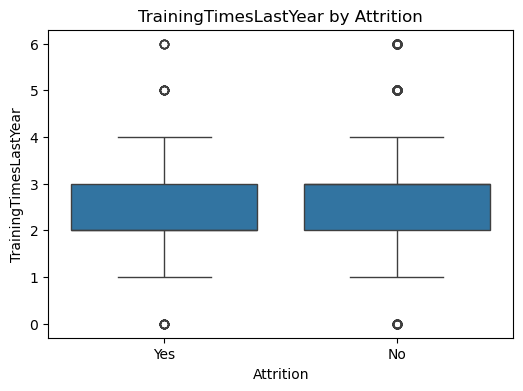

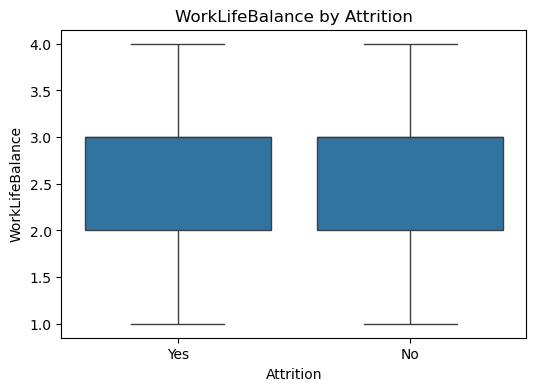

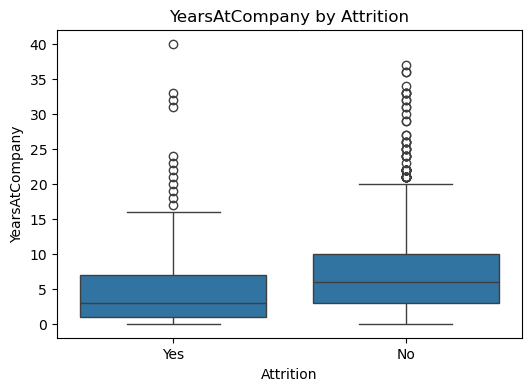

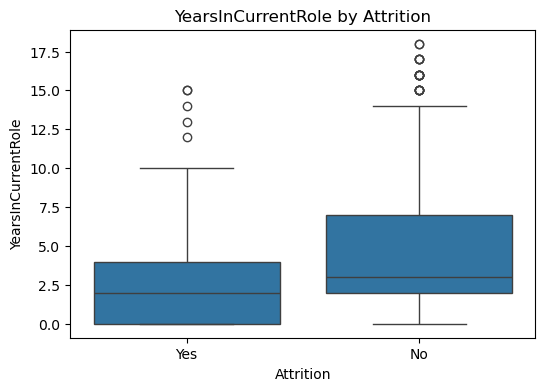

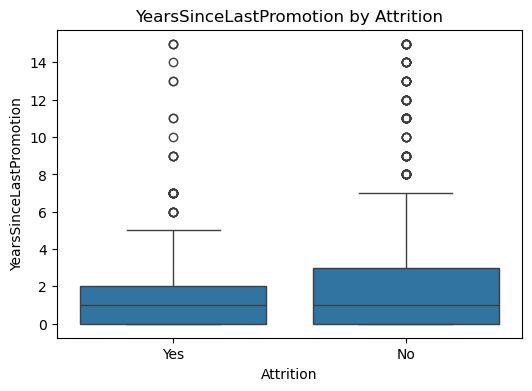

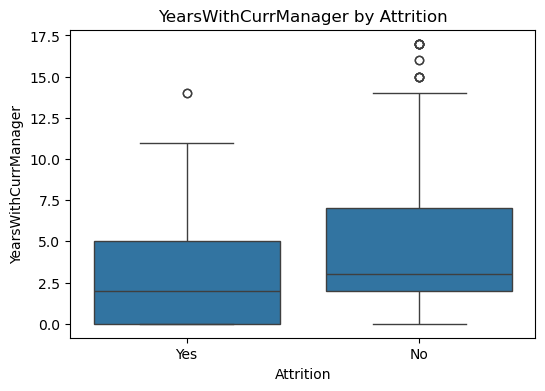

In [16]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Attrition", y=col, data=df)
    plt.title(f"{col} by Attrition")
    plt.show

In [17]:
df.duplicated().sum()

0

In [18]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [19]:
for col in categorical_cols:
    df[col] = df[col].str.strip().str.title()

In [20]:
df.dtypes


Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [21]:
df['Attrition'] = df['Attrition'].astype('category')

In [22]:
df.dtypes


Age                            int64
Attrition                   category
BusinessTravel                object
DailyRate                      int64
Department                    object
DistanceFromHome               int64
Education                      int64
EducationField                object
EmployeeCount                  int64
EmployeeNumber                 int64
EnvironmentSatisfaction        int64
Gender                        object
HourlyRate                     int64
JobInvolvement                 int64
JobLevel                       int64
JobRole                       object
JobSatisfaction                int64
MaritalStatus                 object
MonthlyIncome                  int64
MonthlyRate                    int64
NumCompaniesWorked             int64
Over18                        object
OverTime                      object
PercentSalaryHike              int64
PerformanceRating              int64
RelationshipSatisfaction       int64
StandardHours                  int64
S

In [23]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [24]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [25]:
df.duplicated().sum()

0

In [26]:
df.dtypes


Age                            int64
Attrition                   category
BusinessTravel                object
DailyRate                      int64
Department                    object
DistanceFromHome               int64
Education                      int64
EducationField                object
EmployeeCount                  int64
EmployeeNumber                 int64
EnvironmentSatisfaction        int64
Gender                        object
HourlyRate                     int64
JobInvolvement                 int64
JobLevel                       int64
JobRole                       object
JobSatisfaction                int64
MaritalStatus                 object
MonthlyIncome                  int64
MonthlyRate                    int64
NumCompaniesWorked             int64
Over18                        object
OverTime                      object
PercentSalaryHike              int64
PerformanceRating              int64
RelationshipSatisfaction       int64
StandardHours                  int64
S

In [27]:
from scipy.stats import chi2_contingency

In [28]:
chi2_results ={}

In [29]:
for col in category_cols:
    contingency_table=pd.crosstab(df[col], df['Attrition'])
    chi2,p,dof,expected=chi2_contingency(contingency_table)
    chi2_results[col] = p

In [30]:
sorted_chi2 = dict(sorted(chi2_results.items(), key=lambda item: item[1]))
print(sorted_chi2)

{'OverTime': 8.15842372153832e-21, 'JobRole': 2.752481638050657e-15, 'MaritalStatus': 9.45551106034083e-11, 'BusinessTravel': 5.608614476449931e-06, 'Department': 0.004525606574479633, 'EducationField': 0.006773980139025212, 'Gender': 0.29057244902890855, 'Over18': 1.0}


In [31]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [32]:
df['Attrition_encoded'] = df['Attrition'].apply(lambda x: 1 if x=="Yes" else 0)

In [33]:
numeric_corr = df[numerical_cols].corrwith(df['Attrition_encoded']).sort_values(ascending=False)
print(numeric_corr)

DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
EmployeeCount                    NaN
StandardHours                    NaN
dtype: float64


C:\Users\Mary-Jane\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Mary-Jane\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [34]:
df=df.drop(['EmployeeCount','StandardHours'], axis=1)

In [35]:
#bin creation

In [36]:
df['YearsAtCompany'].describe()

count    1470.000000
mean        7.008163
std         6.126525
min         0.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        40.000000
Name: YearsAtCompany, dtype: float64

In [37]:
bins = [0,3,6,9,12,40]
labels = ['0-3', '4-6', '7-9', '10-12', '13+']

df['YearsAtCompany_bin'] = pd.cut(df['YearsAtCompany'], bins=bins, labels=labels)

In [38]:
df['YearsAtCompany_bin'].value_counts()

YearsAtCompany_bin
0-3      426
4-6      382
7-9      252
13+      200
10-12    166
Name: count, dtype: int64

In [39]:
attrition_by_bin = df.groupby('YearsAtCompany_bin')['Attrition'].value_counts(normalize=True).unstack()

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\161783070.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_by_bin = df.groupby('YearsAtCompany_bin')['Attrition'].value_counts(normalize=True).unstack()


In [40]:
attrition_rate = attrition_by_bin['Yes']
print(attrition_rate)

YearsAtCompany_bin
0-3      0.248826
4-6      0.128272
7-9      0.111111
10-12    0.120482
13+      0.090000
Name: Yes, dtype: float64


In [41]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

In [42]:
attrition_table = {}

for col in numerical_cols:
    df[f'{col}_bin'] = pd.qcut(df[col], q=4, duplicates='drop')
    attrition_by_bin = df.groupby(f"{col}_bin")['Attrition'].value_counts(normalize=True).unstack()
    if 'Yes' in attrition_by_bin.columns:
        attrition_table[col]= attrition_by_bin['Yes']

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\1792593210.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_by_bin = df.groupby(f"{col}_bin")['Attrition'].value_counts(normalize=True).unstack()
C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\1792593210.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_by_bin = df.groupby(f"{col}_bin")['Attrition'].value_counts(normalize=True).unstack()
C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\1792593210.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. P

In [43]:
attrition_summary = pd.concat(attrition_table, axis=1)
print(attrition_summary)

                         Age  DailyRate  DistanceFromHome  Education  \
(17.999, 30.0]      0.259067        NaN               NaN        NaN   
(30.0, 36.0]        0.160194        NaN               NaN        NaN   
(36.0, 43.0]        0.089231        NaN               NaN        NaN   
(43.0, 60.0]        0.121037        NaN               NaN        NaN   
(101.999, 465.0]         NaN   0.200542               NaN        NaN   
(465.0, 802.0]           NaN   0.160763               NaN        NaN   
(802.0, 1157.0]          NaN   0.152589               NaN        NaN   
(1157.0, 1499.0]         NaN   0.130790               NaN        NaN   
(0.999, 2.0]             NaN        NaN          0.128878   0.165929   
(2.0, 7.0]               NaN        NaN          0.143258        NaN   
(7.0, 14.0]              NaN        NaN          0.173529        NaN   
(14.0, 29.0]             NaN        NaN          0.205634        NaN   
(2.0, 3.0]               NaN        NaN               NaN   0.17

In [44]:
numeric_targetcols = ['Age', 'DailyRate', 'EnvironmentSatisfaction','JobSatisfaction','JobInvolvement','PerformanceRating','TotalWorkingYears',
                      'YearsWithCurrManager','YearsInCurrentRole']
attrition_table_numeric = {}

for col in numeric_targetcols:
    df[f'{col}_bin'] = pd.qcut(df[col],q=4,duplicates='drop')
    attrition_by_bin = df.groupby(f'{col}_bin')['Attrition'].value_counts(normalize=True).unstack()
    if 'Yes' in attrition_by_bin.columns:
        attrition_table_numeric[col]=attrition_by_bin['Yes']
print(attrition_table_numeric)

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\3496945012.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_by_bin = df.groupby(f'{col}_bin')['Attrition'].value_counts(normalize=True).unstack()
C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\3496945012.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_by_bin = df.groupby(f'{col}_bin')['Attrition'].value_counts(normalize=True).unstack()
C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\3496945012.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. P

{'Age': Age_bin
(17.999, 30.0]    0.259067
(30.0, 36.0]      0.160194
(36.0, 43.0]      0.089231
(43.0, 60.0]      0.121037
Name: Yes, dtype: float64, 'DailyRate': DailyRate_bin
(101.999, 465.0]    0.200542
(465.0, 802.0]      0.160763
(802.0, 1157.0]     0.152589
(1157.0, 1499.0]    0.130790
Name: Yes, dtype: float64, 'EnvironmentSatisfaction': EnvironmentSatisfaction_bin
(0.999, 2.0]    0.201401
(2.0, 3.0]      0.136865
(3.0, 4.0]      0.134529
Name: Yes, dtype: float64, 'JobSatisfaction': JobSatisfaction_bin
(0.999, 2.0]    0.196837
(2.0, 3.0]      0.165158
(3.0, 4.0]      0.113290
Name: Yes, dtype: float64, 'JobInvolvement': JobInvolvement_bin
(0.999, 2.0]    0.216157
(2.0, 3.0]      0.144009
(3.0, 4.0]      0.090278
Name: Yes, dtype: float64, 'PerformanceRating': PerformanceRating_bin
(2.999, 4.0]    0.161224
Name: Yes, dtype: float64, 'TotalWorkingYears': TotalWorkingYears_bin
(-0.001, 6.0]    0.256236
(6.0, 10.0]      0.143154
(10.0, 15.0]     0.125654
(15.0, 40.0]     0.087079


C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\3496945012.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_by_bin = df.groupby(f'{col}_bin')['Attrition'].value_counts(normalize=True).unstack()
C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\3496945012.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_by_bin = df.groupby(f'{col}_bin')['Attrition'].value_counts(normalize=True).unstack()


In [45]:
category_targetcols = ['OverTime', 'JobRole', 'MaritalStatus', 'BusinessTravel']
attrition_table_categorical = {}

for col in category_targetcols:
    attrition_rate = df.groupby(col)['Attrition'].value_counts(normalize=True).unstack()
    if 'Yes' in attrition_rate.columns:
        attrition_table_categorical[col] = attrition_rate['Yes']
attrition_summary_categorical = pd.concat(attrition_table_categorical,axis=1)
print(attrition_summary_categorical)

                           OverTime   JobRole  MaritalStatus  BusinessTravel
No                         0.104364       NaN            NaN             NaN
Yes                        0.305288       NaN            NaN             NaN
Healthcare Representative       NaN  0.068702            NaN             NaN
Human Resources                 NaN  0.230769            NaN             NaN
Laboratory Technician           NaN  0.239382            NaN             NaN
Manager                         NaN  0.049020            NaN             NaN
Manufacturing Director          NaN  0.068966            NaN             NaN
Research Director               NaN  0.025000            NaN             NaN
Research Scientist              NaN  0.160959            NaN             NaN
Sales Executive                 NaN  0.174847            NaN             NaN
Sales Representative            NaN  0.397590            NaN             NaN
Divorced                        NaN       NaN       0.100917             NaN

In [46]:
attrition_summary_numeric['TotalWorkingYears'].plot(kind='bar',figsize=(6,4))
plt.title('Attrition Rate by Years at Company')
plt.ylabel('Attrition Rate')
plt.xlabel('Years at Company Bin')
plt.show()

NameError: name 'attrition_summary_numeric' is not defined

In [52]:
def plot_attrition_rate(df,column):
    attrition = df.groupby(column)['Attrition'].value_counts(normalize=True).unstack()
    if 'Yes' in attrition.columns:
        attrition['Yes'].plot(kind='bar')
        plt.title(f"Attrition Rate by {column}")
        plt.xlabel(column)
        plt.show()

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\3943733755.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition = df.groupby(column)['Attrition'].value_counts(normalize=True).unstack()


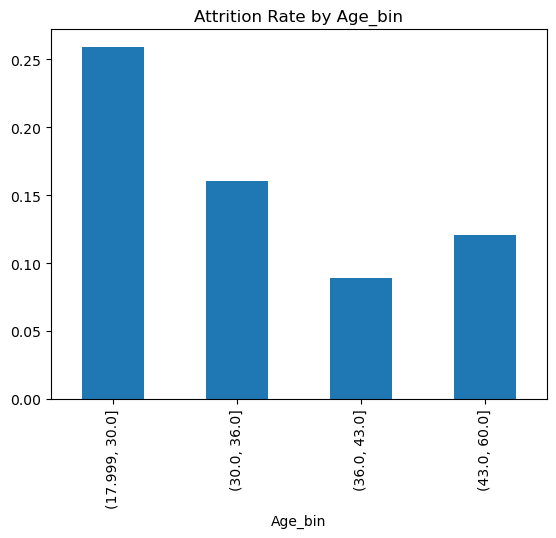

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\3943733755.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition = df.groupby(column)['Attrition'].value_counts(normalize=True).unstack()


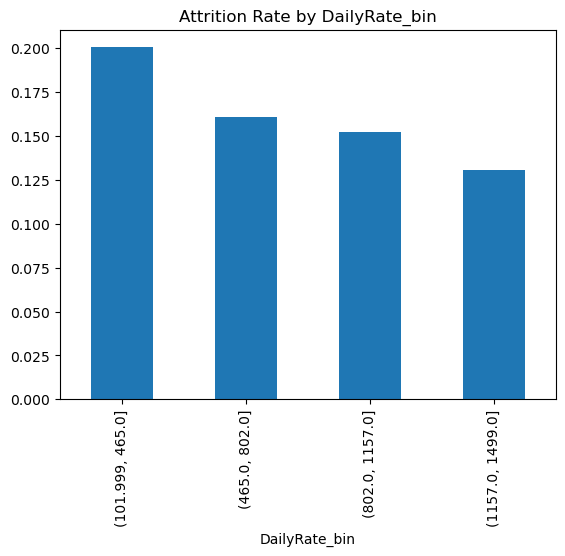

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\3943733755.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition = df.groupby(column)['Attrition'].value_counts(normalize=True).unstack()


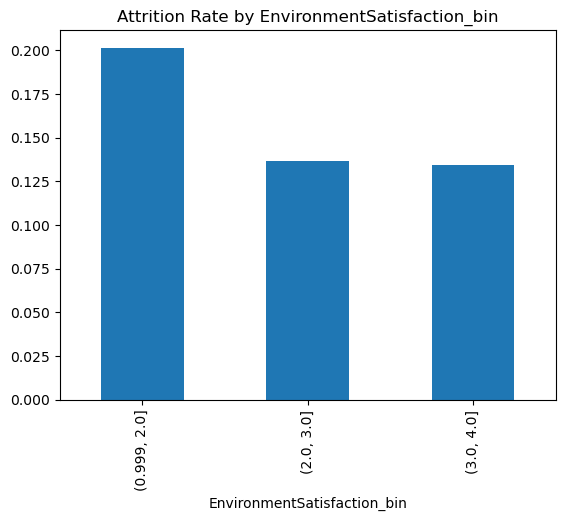

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\3943733755.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition = df.groupby(column)['Attrition'].value_counts(normalize=True).unstack()


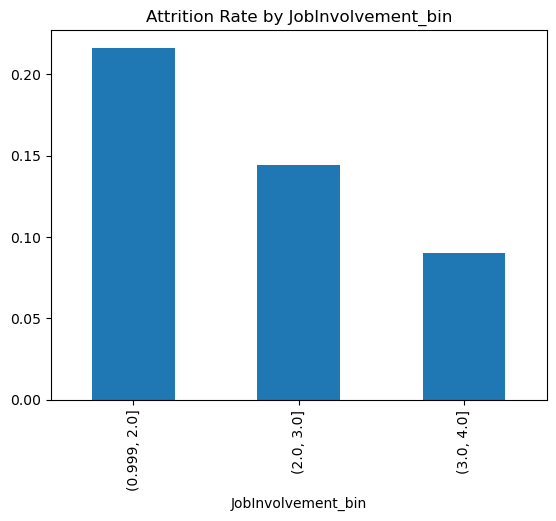

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\3943733755.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition = df.groupby(column)['Attrition'].value_counts(normalize=True).unstack()


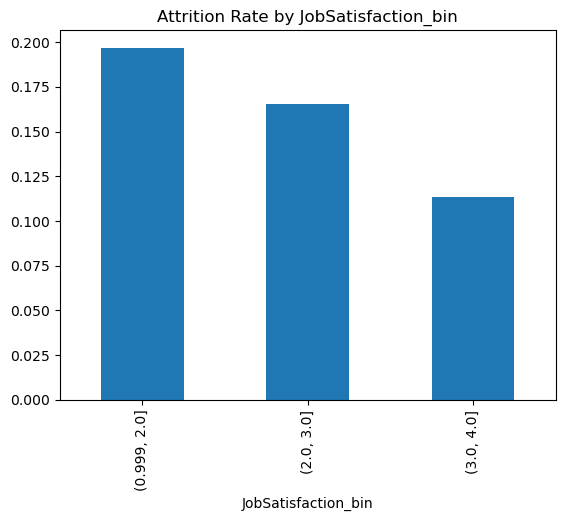

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\3943733755.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition = df.groupby(column)['Attrition'].value_counts(normalize=True).unstack()


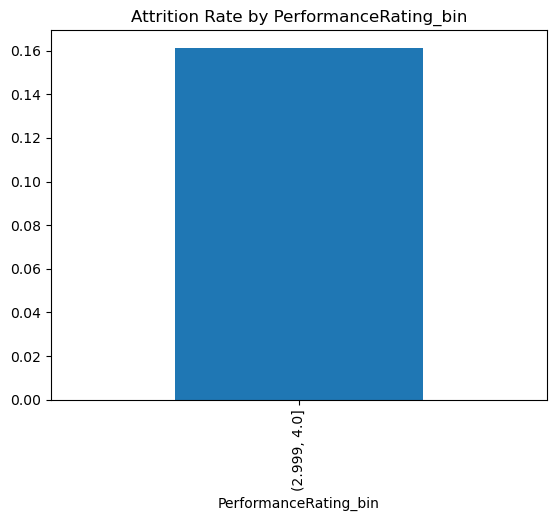

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\3943733755.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition = df.groupby(column)['Attrition'].value_counts(normalize=True).unstack()


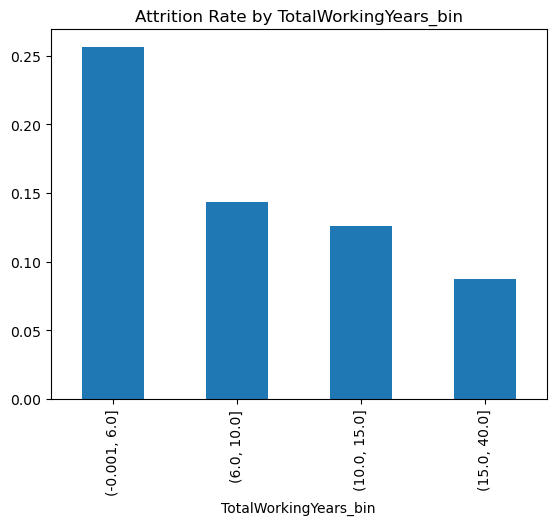

C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_17844\3943733755.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition = df.groupby(column)['Attrition'].value_counts(normalize=True).unstack()


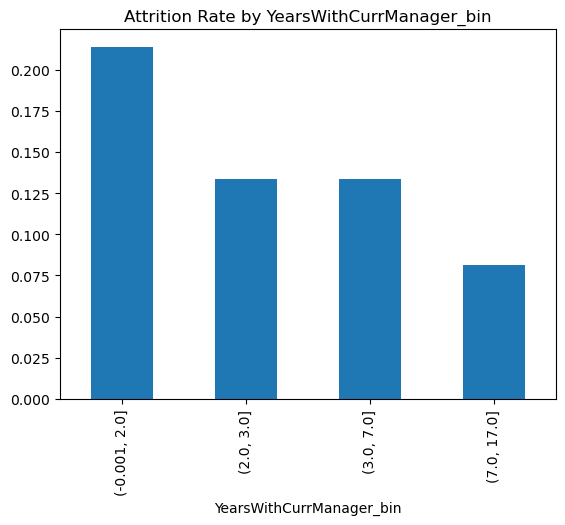

In [54]:
plot_attrition_rate(df, 'Age_bin')
plot_attrition_rate(df, 'DailyRate_bin')
plot_attrition_rate(df, 'EnvironmentSatisfaction_bin')
plot_attrition_rate(df, 'JobInvolvement_bin')
plot_attrition_rate(df, 'JobSatisfaction_bin')
plot_attrition_rate(df, 'PerformanceRating_bin')
plot_attrition_rate(df, 'TotalWorkingYears_bin')
plot_attrition_rate(df, 'YearsWithCurrManager_bin')



pandas.core.frame.DataFrame